## 1- Library import

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import networkx as nx
import statsmodels.api as sm


## 2 - Directed Acyclic Graph

C:\Users\HP GUEST\AppData\Local\Temp\ipykernel_2184\2201948406.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


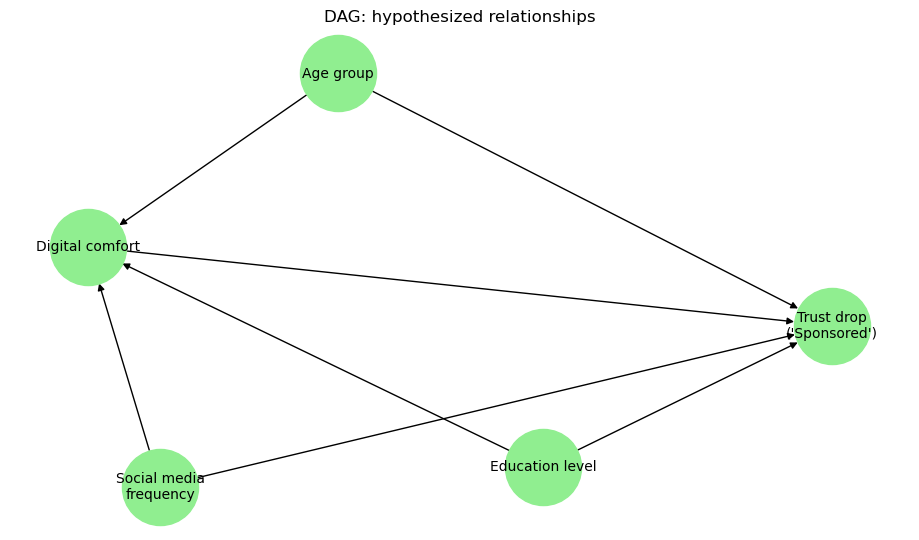

In [24]:
# DAG: what influences what
G = nx.DiGraph()

nodes = [
    "Age group",
    "Education level",
    "Social media\nfrequency",
    "Digital comfort",
    "Trust drop\n('Sponsored')"
]
G.add_nodes_from(nodes)

edges = [
    ("Age group", "Digital comfort"),
    ("Education level", "Digital comfort"),
    ("Social media\nfrequency", "Digital comfort"),

    ("Age group", "Trust drop\n('Sponsored')"),
    ("Education level", "Trust drop\n('Sponsored')"),
    ("Social media\nfrequency", "Trust drop\n('Sponsored')"),

    # Main hypothesis
    ("Digital comfort", "Trust drop\n('Sponsored')")
]
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(9, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=3000,
    node_color="lightgreen",
    arrows=True,
    font_size=10
)
plt.title("DAG: hypothesized relationships")
plt.tight_layout()
plt.show()


## 3 - Data import

In [19]:
df = pd.read_csv("ads2.csv")

# Renaming
rename_map = {
    "À quelle fréquence utilisez vous les réseaux sociaux ?": "social_freq",
    "Vous considérez vous à l’aise avec les outils numériques (applications, sites web, plateformes en ligne) ?": "digital_comfort",
    "Diriez vous que la présence de la mention “sponsorisé” Diminue fortement votre confiance ?": "trust_drop",
    "Tranche d’âge :": "age_group",
    "Niveau d’études :": "education_level",
}

df = df.rename(columns=rename_map)

# Cleaning the Nan
for c in ["social_freq", "digital_comfort", "trust_drop", "age_group", "education_level"]:
    df[c] = df[c].astype("string").str.strip()

print(df.columns.tolist())
df.head()


['Horodateur', 'social_freq', 'digital_comfort', 'trust_drop', 'age_group', 'education_level']


,Horodateur,social_freq,digital_comfort,trust_drop,age_group,education_level
0,2025/12/30 2:21:27 PM UTC+1,Plusieurs fois par jour,Totalement d'accord,Pas du tout d'accord,18–24,Université
1,2025/12/30 2:21:31 PM UTC+1,<NA>,<NA>,<NA>,<NA>,<NA>
2,2025/12/30 2:24:42 PM UTC+1,Plusieurs fois par jour,Pas d'accord,Totalement d'accord,18–24,Université
3,2025/12/30 2:25:39 PM UTC+1,Plusieurs fois par jour,Pas d'accord,Neutre,18–24,Université
4,2025/12/30 2:25:45 PM UTC+1,Une fois par jour,Totalement d'accord,Neutre,18–24,Université


## 4 - Data manipulation

In [20]:
likert_map = {
    "Pas du tout d'accord": 1,
    "Pas d'accord": 2,
    "Neutre": 3,
    "D'accord": 4,
    "Totalement d'accord": 5
}

freq_map = {
    "Rarement": 1,
    "Quelques fois par semaine": 2,
    "Une fois par jour": 3,
    "Plusieurs fois par jour": 4
}

age_map = {
    "–18": 1,
    "18–24": 2,
    "25–34": 3,
    "35–44": 4
}

edu_map = {
    "Collège / lycée": 1,
    "Université": 2,
    "Autre": 3
}

df["digital_comfort_score"] = df["digital_comfort"].map(likert_map)
df["trust_drop_score"] = df["trust_drop"].map(likert_map)
df["freq_score"] = df["social_freq"].map(freq_map)
df["age_score"] = df["age_group"].map(age_map)
df["edu_score"] = df["education_level"].map(edu_map)

# Cleaning 
missing = df[["digital_comfort_score","trust_drop_score","freq_score","age_score","edu_score"]].isna().sum()
print("Missing values per encoded variable:\n", missing)


Missing values per encoded variable:
 digital_comfort_score    3
trust_drop_score         7
freq_score               2
age_score                3
edu_score                3
dtype: int64


### 5- Data description

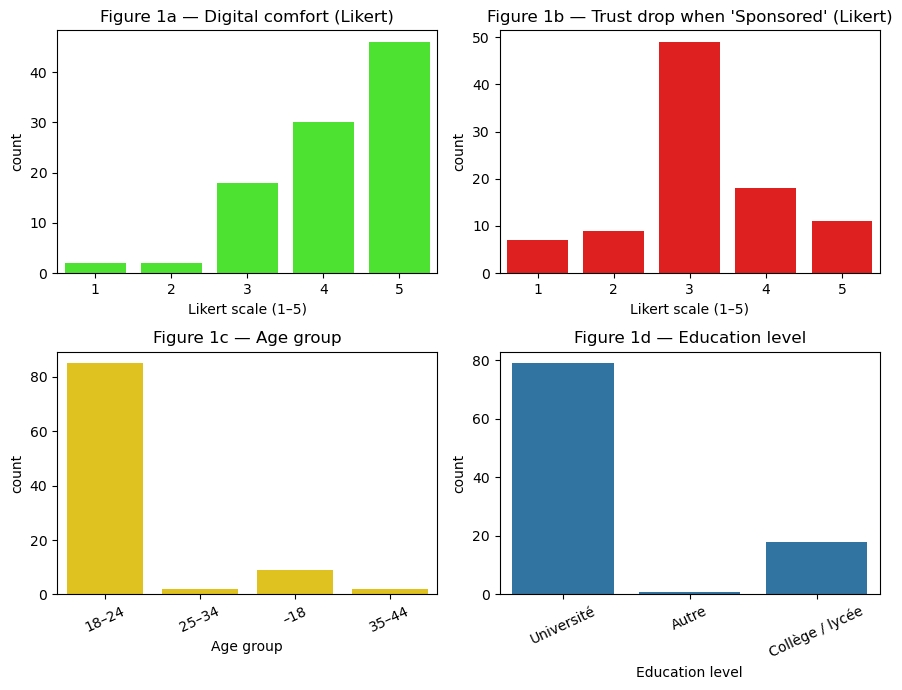

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))

# Digital comfort (Likert) — vert fluo
sns.countplot(
    x=df.loc[df["digital_comfort_score"].notna(), "digital_comfort_score"].astype(int),
    order=[1, 2, 3, 4, 5],
    ax=axs[0, 0],
    color="#39FF14"  # vert fluo
)
axs[0, 0].set_title("Figure 1a — Digital comfort (Likert)")
axs[0, 0].set_xlabel("Likert scale (1–5)")

# Trust drop (Likert) — rouge
sns.countplot(
    x=df.loc[df["trust_drop_score"].notna(), "trust_drop_score"].astype(int),
    order=[1, 2, 3, 4, 5],
    ax=axs[0, 1],
    color="#FF0000"  # rouge
)
axs[0, 1].set_title("Figure 1b — Trust drop when 'Sponsored' (Likert)")
axs[0, 1].set_xlabel("Likert scale (1–5)")

# Age group — jaune
sns.countplot(
    x=df.loc[df["age_group"].notna(), "age_group"],
    ax=axs[1, 0],
    color="#FFD700"  # jaune (gold)
)
axs[1, 0].set_title("Figure 1c — Age group")
axs[1, 0].set_xlabel("Age group")
axs[1, 0].tick_params(axis="x", rotation=25)

# Education level — (garde couleur par défaut ou choisis-en une)
sns.countplot(
    x=df.loc[df["education_level"].notna(), "education_level"],
    ax=axs[1, 1]
)
axs[1, 1].set_title("Figure 1d — Education level")
axs[1, 1].set_xlabel("Education level")
axs[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


### 6 - Data modelling

We computed the following mixed linear model:
$$
\text{TrustDrop}_i
= \beta_0
+ \beta_1\,\text{DigitalComfort}_{z,i}
+ \beta_2\,\text{Freq}_{z,i}
+ \beta_3\,\text{Age}_{z,i}
+ \beta_4\,\text{Edu}_{z,i}
+ \varepsilon_i
$$

In [22]:
model_df = df[["trust_drop_score","digital_comfort_score","freq_score","age_score","edu_score"]].dropna()

X = model_df[["digital_comfort_score","freq_score","age_score","edu_score"]]
y = model_df["trust_drop_score"]

# Standardization (z-scores)
Xz = (X - X.mean()) / X.std(ddof=0)
Xz = sm.add_constant(Xz)

ols = sm.OLS(y, Xz).fit()
ols_r = ols.get_robustcov_results(cov_type="HC3")  # robuste

print(ols_r.summary())


                            OLS Regression Results                            
Dep. Variable:       trust_drop_score   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                     1.177
Date:                Wed, 28 Jan 2026   Prob (F-statistic):              0.327
Time:                        11:14:02   Log-Likelihood:                -130.02
No. Observations:                  92   AIC:                             270.0
Df Residuals:                      87   BIC:                             282.6
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     3.16

### 7 - Forest plot

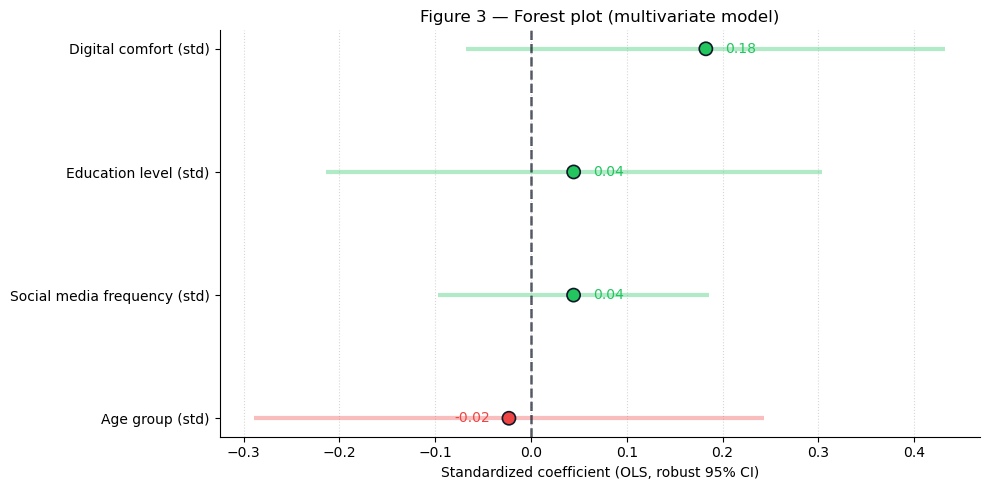

In [23]:

# --- Extract params + CI ---
names = ols_r.model.exog_names
params = pd.Series(ols_r.params, index=names)
conf = pd.DataFrame(ols_r.conf_int(), index=names, columns=["low","high"])

# Remove intercept
params = params.drop(["Intercept", "const"], errors="ignore")
conf = conf.drop(["Intercept", "const"], errors="ignore")

#  labels
labels = {
    "digital_comfort_score": "Digital comfort (std)",
    "freq_score": "Social media frequency (std)",
    "age_score": "Age group (std)",
    "edu_score": "Education level (std)"
}
params.index = [labels.get(i, i) for i in params.index]
conf.index = params.index

# Seffect size
order = params.abs().sort_values().index
params = params.loc[order]
conf = conf.loc[order]

# Colors by sign
# positive = green, negative = red
colors = np.where(params.values >= 0, "#22c55e", "#ef4444")

ypos = np.arange(len(params))

plt.figure(figsize=(10, 0.7 * len(params) + 2.2))

# Confidence intervals (horizontal lines)
for i, (lo, hi, col) in enumerate(zip(conf["low"].values, conf["high"].values, colors)):
    plt.hlines(y=i, xmin=lo, xmax=hi, linewidth=3, color=col, alpha=0.35)

# Points 
plt.scatter(params.values, ypos, s=90, c=colors, edgecolors="#111827", linewidths=1.2, zorder=3)

# 0 line
plt.axvline(0, linestyle="--", linewidth=1.8, color="#111827", alpha=0.7)

# Labels + style
plt.yticks(ypos, params.index)
plt.xlabel("Standardized coefficient (OLS, robust 95% CI)")
plt.title("Figure 3 — Forest plot (multivariate model)")

# Clean grid
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.gca().set_axisbelow(True)

#  subtle frame cleanup
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

# annotate coefficient values 
for x, y, col in zip(params.values, ypos, colors):
    ha = "left" if x >= 0 else "right"
    dx = 0.02 if x >= 0 else -0.02
    plt.text(x + dx, y, f"{x:.2f}", va="center", ha=ha, fontsize=10, color=col)

plt.tight_layout()
plt.show()
